# Eye Disease Classification with CNN Backbones (EfficientNet, DenseNet, ResNet)

## Objective
This notebook trains multiple CNN models (**EfficientNet-B0, DenseNet121, and ResNet50**) for multiclass eye disease classification using the prepared RGB eye image augmented dataset.

All models use **ImageNet pretrained weights** and are adapted using transfer learning for this task.

The goal is to build a structured training, validation, evaluation, and explainability pipeline that is easy to understand, reproducible, and suitable for comparing different model strategies.

## Models Covered in This Notebook
This notebook supports training and evaluation of the following models:

- EfficientNet-B0 (ImageNet pretrained)
- DenseNet121 (ImageNet pretrained)
- ResNet50 (ImageNet pretrained)

Each model:
- uses ImageNet pretrained weights
- follows the same training pipeline
- is trained and evaluated independently
- is compared using identical evaluation metrics

This ensures a fair and consistent comparison across architectures.

## What is ImageNet Pretraining?
**ImageNet** is a large-scale dataset containing millions of labeled images across thousands of categories.

Models pretrained on ImageNet have already learned:
- general visual features such as edges, textures, and shapes
- mid-level patterns like object parts
- high-level representations useful for classification tasks

In this notebook:
- all models start with **ImageNet pretrained weights**
- the final classification layers are replaced to match the eye disease classes
- the models are then fine-tuned on the eye disease dataset

This approach is called **transfer learning** and helps:
- reduce training time
- improve performance, especially with limited medical data
- stabilize training

## CNN Backbones Used in This Notebook

This notebook uses three popular convolutional neural network architectures:

### 1. EfficientNet-B0
- balanced scaling of depth, width, and resolution
- lightweight and efficient
- strong baseline for transfer learning

### 2. DenseNet121
- dense connections between layers
- improves feature reuse
- often performs well on medical imaging tasks

### 3. ResNet50
- residual connections help train deeper networks
- widely used and well-understood baseline
- strong general-purpose performance

## Notebook Location
This notebook is intended to live inside:

`nbs/training_validation_explainability/model_comparison_rgb/`

## Dataset Location
The prepared RGB datasets are expected at:

- `../../../res/rgb_v1/data/aug/train`
- `../../../res/rgb_v1/data/aug/validate`

## How the Dataset is Used
The dataset is used in the following way:

- `../../../res/rgb_v1/data/aug/train` contains the augmented RGB training images used for model development
- `../../../res/rgb_v1/data/aug/validate` contains a separate holdout RGB validation dataset used only for final evaluation

To support model training and checkpoint selection, the augmented training dataset is further split into:

- **70% Training Split**
- **30% Internal Validation Split**

### Important Note
The holdout validation dataset is **not used during training**.  
It is kept separate and used only after training is complete.

## Training Configuration
This notebook uses the following default training configuration:

- **Image Size:** 224 × 224
- **Batch Size:** 32
- **Stage 1 Epochs:** 5
- **Stage 2 Epochs:** 10
- **Total Epochs:** 15
- **Stage 1 Learning Rate:** 0.001
- **Stage 2 Learning Rate:** 0.0001
- **Dropout:** 0.3
- **Validation Split from Training Data:** 30%

## What is an Epoch?
An **epoch** means one complete pass through the full training split.

In this notebook, training happens in two stages:
- **Stage 1:** 5 epochs
- **Stage 2:** 10 epochs

So the notebook runs for **15 total epochs by default**, unless the configuration is changed manually.

## What is a Batch?
A **batch** is a small group of images processed together in one iteration during training.

This notebook uses:

- **Batch Size = 32**

That means the model processes 32 images at a time before updating its weights.

If the training split contains many images, one epoch will contain multiple batches.

For example, a progress bar like `35/75` means:
- 35 batches completed
- out of 75 total batches in that epoch

## Training Flow
The training process happens in two stages.

### Stage 1: Head Training
- the backbone is frozen
- only the final classification layer is trained

This helps the model first adapt to the eye disease classes without changing the pretrained backbone too early.

### Stage 2: Fine-Tuning
- the backbone feature extraction layers are unfrozen
- the model is trained again using a smaller learning rate

This allows the pretrained backbone to adapt more specifically to the eye disease dataset.

## Best Checkpoint Selection Rule
The best checkpoint is selected using a simple and consistent rule:

1. choose the checkpoint with the **highest internal validation accuracy**
2. if two checkpoints have similar validation accuracy, choose the one with the **lower internal validation loss**

## Checkpoint Saving Strategy
This notebook saves **only the best-performing checkpoint**, not a separate checkpoint for every epoch.

A new checkpoint is saved only when the current epoch performs better than the previously saved best checkpoint.

## Saved Artifacts
This notebook produces and saves the following artifacts:

### Model Artifact
- best model checkpoint in `.pth` format

### Plot Artifacts
- training vs internal validation accuracy curve
- training vs internal validation loss curve
- confusion matrix plots

### Explainability Outputs
- Grad-CAM visualizations
- Occlusion Sensitivity maps
- Integrated Gradients maps

## Evaluation Strategy

### 1. Internal Validation Evaluation
Used for:
- monitoring performance during training
- checkpoint selection

### 2. Holdout Validation Evaluation
Performed on:

`../../../res/rgb_v1/data/aug/validate`

Used for final model comparison.

## Metrics Reported

- accuracy
- loss
- precision
- recall
- F1-score
- macro F1
- weighted F1
- confusion matrix
- classification report

## Explainability Strategy

### Grad-CAM
- shows where the model is looking

### Occlusion Sensitivity
- shows what regions matter most

## Final Outcome
By the end of this notebook, we will have:

- trained multiple ImageNet-pretrained CNN models
- selected the best checkpoint using internal validation performance
- evaluated models on both internal and holdout datasets
- compared performance across architectures
- prepared the pipeline for explainability analysis

In [1]:
# ==============================
# Standard Libraries
# ==============================
import os
import copy
import time
import random
from pathlib import Path
from collections import defaultdict

# ==============================
# Data & Numerical Libraries
# ==============================
import numpy as np
import pandas as pd
from PIL import Image

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Utilities
# ==============================
from tqdm.auto import tqdm

# ==============================
# PyTorch Core
# ==============================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

# ==============================
# Torchvision (Datasets + Models)
# ==============================
from torchvision import datasets, models, transforms

# ==============================
# Sklearn (Splitting + Metrics)
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

# ==============================
# Explainability
# ==============================
from captum.attr import IntegratedGradients, Occlusion

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

/home/jovyan/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

This section defines the core experiment settings used throughout the notebook.

These values control:
- dataset paths
- model artifact locations
- image size
- batch size
- number of epochs
- learning rates
- dropout
- validation split
- device selection

### Path Configuration
The training and holdout validation dataset paths are defined relative to the notebook location.

The notebook also creates local folders for:
- model checkpoints
- plots
- other run artifacts

### Training Configuration
This block sets the main training hyperparameters for the experiment, including:
- image resolution
- batch size
- number of workers
- stage 1 and stage 2 epoch counts
- learning rates for both stages
- dropout value
- internal validation split ratio

### Device Configuration
The notebook automatically detects whether GPU is available.

- if CUDA is available, training uses GPU
- otherwise, training runs on CPU

### Quick Validation Check
At the end of this section, the notebook prints:
- the selected device
- whether the training path exists
- whether the holdout validation path exists

This is a simple sanity check to confirm that the notebook is pointing to the expected dataset folders before training begins.

In [2]:
SEED = 42

# Dataset Paths
TRAIN_ROOT = Path("efficientnetdataset/train")
HOLDOUT_ROOT = Path("efficientnetdataset/validate")

# Artifact Directories
MODEL_DIR = Path("./models")
PLOT_DIR = Path("./plots")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Model Configuration (generic for multi-model support)
MODEL_NAME = "cnn_model_comparison_eye_disease"
BEST_MODEL_PATH = None

# Training Configuration
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

NUM_EPOCHS_STAGE1 = 5
NUM_EPOCHS_STAGE2 = 10

LEARNING_RATE_STAGE1 = 1e-3
LEARNING_RATE_STAGE2 = 1e-4

DROPOUT = 0.3
VAL_SPLIT = 0.30

# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sanity Check
print("DEVICE:", DEVICE)
print("TRAIN_ROOT exists:", TRAIN_ROOT.exists(), TRAIN_ROOT.resolve())
print("HOLDOUT_ROOT exists:", HOLDOUT_ROOT.exists(), HOLDOUT_ROOT.resolve())

DEVICE: cuda
TRAIN_ROOT exists: True /home/jovyan/efficientnetdataset/train
HOLDOUT_ROOT exists: True /home/jovyan/efficientnetdataset/validate


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Dataset Discovery

We first scan the training and holdout folders to understand:

- class names
- image counts
- whether the folder structure is correct

In [4]:
base_dataset = datasets.ImageFolder(TRAIN_ROOT)
class_names = base_dataset.classes
class_to_idx = base_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Classes:", class_names)
print("Class to index:", class_to_idx)
print("Number of classes:", len(class_names))


Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Class to index: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}
Number of classes: 4


In [5]:
def count_images_in_folder(root_path):
    ds = datasets.ImageFolder(root_path)
    counts = defaultdict(int)
    for _, label in ds.samples:
        counts[ds.classes[label]] += 1
    return pd.DataFrame({
        "class_name": list(counts.keys()),
        "count": list(counts.values())
    }).sort_values("class_name").reset_index(drop=True)

train_counts_df = count_images_in_folder(TRAIN_ROOT)
holdout_counts_df = count_images_in_folder(HOLDOUT_ROOT)

print("Augmented Train Folder Counts")
display(train_counts_df)

print("Holdout Validation Folder Counts")
display(holdout_counts_df)


Augmented Train Folder Counts


,class_name,count
0,cataract,2000
1,diabetic_retinopathy,2000
2,glaucoma,2000
3,normal,2000


Holdout Validation Folder Counts


,class_name,count
0,cataract,20
1,diabetic_retinopathy,13
2,glaucoma,20
3,normal,20


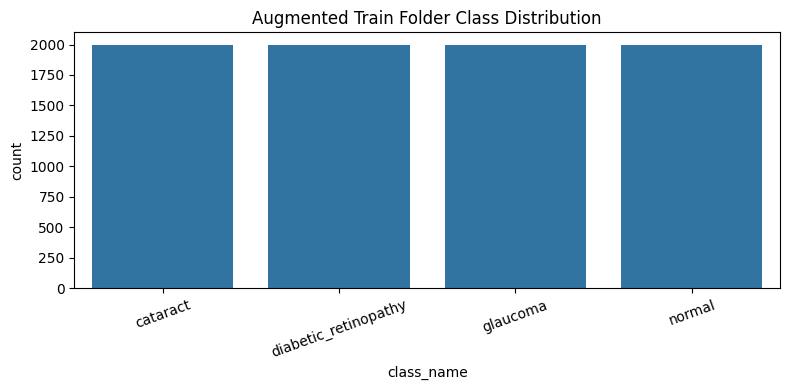

In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(data=train_counts_df, x="class_name", y="count")
plt.title("Augmented Train Folder Class Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Preprocessing

All models in this notebook (EfficientNet-B0, DenseNet121, ResNet50) expect **RGB images** in a standardized numeric format before they are passed to the model.

The following preprocessing steps are applied:

- **Resize** all images to **224 × 224**
- **Convert** images to tensors
- **Normalize** pixel values using **ImageNet mean and standard deviation**

### Why is this needed?
All models are initialized with **ImageNet pretrained weights**, so the input images must follow the same preprocessing convention used during ImageNet training.

This helps:
- keep the input format consistent
- improve training stability
- make transfer learning more effective

In [7]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [8]:
full_dataset = datasets.ImageFolder(TRAIN_ROOT, transform=train_transform)

targets = [label for _, label in full_dataset.samples]
indices = np.arange(len(targets))

train_indices, val_indices = train_test_split(
    indices,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=targets
)

train_dataset = Subset(full_dataset, train_indices)

# Important: use SAME underlying dataset but different transform
full_dataset_eval = datasets.ImageFolder(TRAIN_ROOT, transform=eval_transform)
internal_val_dataset = Subset(full_dataset_eval, val_indices)

holdout_dataset = datasets.ImageFolder(HOLDOUT_ROOT, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

internal_val_loader = DataLoader(
    internal_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

holdout_loader = DataLoader(
    holdout_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train samples:", len(train_dataset))
print("Internal val samples:", len(internal_val_dataset))
print("Holdout val samples:", len(holdout_dataset))

Train samples: 5600
Internal val samples: 2400
Holdout val samples: 73


## Model Definition

We use multiple CNN backbones (**EfficientNet-B0, DenseNet121, and ResNet50**) initialized with pretrained ImageNet weights.

### What is transfer learning?
Transfer learning means starting from a model already trained on a large dataset and adapting it to our eye disease classification task.

This usually helps because:
- training is faster
- less data is needed
- performance is often better than training from scratch

In [9]:
def build_model(model_name: str, num_classes: int, dropout: float = 0.3):
    if model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f"Unsupported model: {model_name}")

    return model


# ==============================
# Initialize All Models
# ==============================
models_to_run = ["efficientnet_b0", "densenet121", "resnet50"]

all_models = {}

for model_name in models_to_run:
    model = build_model(
        model_name=model_name,
        num_classes=len(class_names),
        dropout=DROPOUT
    ).to(DEVICE)

    all_models[model_name] = model

    print(f"\nInitialized Model: {model_name}")
    print(model)


Initialized Model: efficientnet_b0
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
        

In [10]:
criterion = nn.CrossEntropyLoss()

## Helper Functions

This section defines the reusable helper functions used across the training and evaluation workflow.

These functions handle:
- model training for one epoch
- model evaluation on validation data
- checkpoint comparison logic
- metric calculation and reporting

Keeping these functions separate makes the notebook:
- easier to read
- easier to maintain
- easier to debug

## Best Checkpoint Rule

The notebook keeps only the **best checkpoint** during training.

A checkpoint is considered better when:

1. it has a **higher internal validation accuracy**
2. if validation accuracy is the same, or nearly the same, the checkpoint with the **lower internal validation loss** is selected

### Why this rule is used
Since the dataset is balanced across classes, validation accuracy is a strong primary selection metric.

Validation loss is used as a secondary check because it helps choose the more stable model when two checkpoints perform very similarly in terms of accuracy.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    y_true, y_pred = [], []

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(y_true, y_pred)

    return epoch_loss, epoch_acc

In [12]:
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.detach().cpu().numpy())
            y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(y_true, y_pred)
    epoch_macro_f1 = f1_score(y_true, y_pred, average="macro")
    epoch_weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "macro_f1": epoch_macro_f1,
        "weighted_f1": epoch_weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [13]:
def should_save_best(current_acc, current_loss, best_acc, best_loss, tolerance=1e-6):
    if current_acc > best_acc:
        return True
    if abs(current_acc - best_acc) <= tolerance and current_loss < best_loss:
        return True
    return False

In [14]:
def run_training(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs,
    history,
    stage_name,
    current_lr,
    start_epoch=0,
    best_acc=-1.0,
    best_loss=float("inf"),
    best_epoch=-1,
    existing_best_model_path=None
):
    best_model_path = existing_best_model_path

    for epoch in range(start_epoch, start_epoch + num_epochs):
        epoch_start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_results = evaluate_model(model, val_loader, criterion, device)

        epoch_time_taken = time.time() - epoch_start_time

        val_loss = val_results["loss"]
        val_acc = val_results["accuracy"]
        val_macro_f1 = val_results["macro_f1"]
        val_weighted_f1 = val_results["weighted_f1"]

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)
        history["val_weighted_f1"].append(val_weighted_f1)
        history["time_taken_seconds"].append(epoch_time_taken)

        print(
            f"{model_name} | Epoch {epoch + 1} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
            f"val_macro_f1={val_macro_f1:.4f} | "
            f"timeTakenInSeconds={epoch_time_taken:.2f}"
        )

        if should_save_best(val_acc, val_loss, best_acc, best_loss):
            best_acc = val_acc
            best_loss = val_loss
            best_epoch = epoch + 1

            checkpoint_name = (
                f"{model_name}_{stage_name}_epoch_{best_epoch}"
                f"_trainacc_{train_acc:.4f}"
                f"_trainloss_{train_loss:.4f}"
                f"_valacc_{val_acc:.4f}"
                f"_valloss_{val_loss:.4f}"
                f"_macrof1_{val_macro_f1:.4f}.pth"
            )

            best_model_path = MODEL_DIR / checkpoint_name

            checkpoint = {
                "model_name": model_name,
                "stage": stage_name,
                "epoch": best_epoch,
                "batch_size": BATCH_SIZE,
                "image_size": IMAGE_SIZE,
                "learning_rate": current_lr,
                "class_names": class_names,
                "num_classes": len(class_names),
                "num_train_samples": len(train_loader.dataset),
                "num_val_samples": len(val_loader.dataset),
                "num_train_batches": len(train_loader),
                "num_val_batches": len(val_loader),
                "train_accuracy": train_acc,
                "train_loss": train_loss,
                "val_accuracy": val_acc,
                "val_loss": val_loss,
                "val_macro_f1": val_macro_f1,
                "val_weighted_f1": val_weighted_f1,
                "timeTakenInSeconds": epoch_time_taken,
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "optimizer_state_dict": optimizer.state_dict()
            }

            torch.save(checkpoint, best_model_path)
            print(f"Saved new best checkpoint: {best_model_path.name}")

    return history, best_acc, best_loss, best_epoch, best_model_path

## Two-Stage Training: Head Training + Fine-Tuning

Training in this notebook is performed in **two stages for each model (EfficientNet-B0, DenseNet121, ResNet50)**.

This structured approach helps achieve stable learning first, followed by task-specific refinement.

---

### Stage 1: Head Training (Backbone Frozen)

In Stage 1, the pretrained backbone remains **frozen**.

- feature extraction layers are **not updated**
- only the **final classification head** is trained

#### Purpose
This allows the model to:
- learn how to map pretrained features to eye disease classes
- adapt safely without disturbing learned ImageNet features too early

#### Benefit
- stabilizes early training
- reduces risk of overfitting or destructive weight updates

---

### Stage 2: Fine-Tuning (Backbone Unfrozen)

In Stage 2, the entire backbone is **unfrozen** and training continues with a **smaller learning rate**.

#### Purpose
This allows the model to:
- refine pretrained features for eye disease patterns
- improve class separation
- achieve better performance than head-only training

#### Why smaller learning rate?
- prevents large updates to pretrained weights
- enables controlled, gradual adaptation
- preserves useful general features from ImageNet

---

### Overall Training Strategy

For each model:
1. Train classification head (Stage 1)
2. Fine-tune full network (Stage 2)
3. Track validation performance continuously
4. Save only the best checkpoint based on validation metrics

This ensures:
- stable training
- effective transfer learning
- fair comparison across models

In [15]:
models_to_run = ["efficientnet_b0", "densenet121", "resnet50"]

all_results = {}

for model_name in models_to_run:
    print(f"\n========== Training {model_name} ==========\n")

    model = build_model(
        model_name=model_name,
        num_classes=len(class_names),
        dropout=DROPOUT
    ).to(DEVICE)

    # ==============================
    # Stage 1: Freeze Backbone
    # ==============================
    if model_name == "efficientnet_b0":
        for param in model.features.parameters():
            param.requires_grad = False

    elif model_name == "densenet121":
        for param in model.features.parameters():
            param.requires_grad = False

    elif model_name == "resnet50":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True

    optimizer_stage1 = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE_STAGE1
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
        "time_taken_seconds": []
    }

    best_acc, best_loss, best_epoch = -1.0, float("inf"), -1
    BEST_MODEL_PATH = None

    history, best_acc, best_loss, best_epoch, BEST_MODEL_PATH = run_training(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=internal_val_loader,
        criterion=criterion,
        optimizer=optimizer_stage1,
        device=DEVICE,
        num_epochs=NUM_EPOCHS_STAGE1,
        history=history,
        stage_name="stage1",
        current_lr=LEARNING_RATE_STAGE1,
        existing_best_model_path=BEST_MODEL_PATH
    )

    # ==============================
    # Stage 2: Unfreeze Backbone
    # ==============================
    if model_name in ["efficientnet_b0", "densenet121"]:
        for param in model.features.parameters():
            param.requires_grad = True

    elif model_name == "resnet50":
        for param in model.parameters():
            param.requires_grad = True

    optimizer_stage2 = optim.Adam(model.parameters(), lr=LEARNING_RATE_STAGE2)

    history, best_acc, best_loss, best_epoch, BEST_MODEL_PATH = run_training(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=internal_val_loader,
        criterion=criterion,
        optimizer=optimizer_stage2,
        device=DEVICE,
        num_epochs=NUM_EPOCHS_STAGE2,
        history=history,
        stage_name="stage2",
        current_lr=LEARNING_RATE_STAGE2,
        start_epoch=len(history["epoch"]),
        best_acc=best_acc,
        best_loss=best_loss,
        best_epoch=best_epoch,
        existing_best_model_path=BEST_MODEL_PATH
    )

    all_results[model_name] = {
        "history": history,
        "best_acc": best_acc,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
        "best_model_path": BEST_MODEL_PATH
    }

    print(f"\nCompleted {model_name}")
    print("Best Acc:", best_acc)
    print("Best Loss:", best_loss)
    print("Best Epoch:", best_epoch)
    print("Best Model Path:", BEST_MODEL_PATH)


========== Training efficientnet_b0 ==========



efficientnet_b0 | Epoch 1 | train_loss=0.7499 | train_acc=0.7238 | val_loss=0.5159 | val_acc=0.8175 | val_macro_f1=0.8179 | timeTakenInSeconds=30.86
Saved new best checkpoint: efficientnet_b0_stage1_epoch_1_trainacc_0.7238_trainloss_0.7499_valacc_0.8175_valloss_0.5159_macrof1_0.8179.pth


efficientnet_b0 | Epoch 2 | train_loss=0.5463 | train_acc=0.7971 | val_loss=0.4373 | val_acc=0.8471 | val_macro_f1=0.8474 | timeTakenInSeconds=30.95
Saved new best checkpoint: efficientnet_b0_stage1_epoch_2_trainacc_0.7971_trainloss_0.5463_valacc_0.8471_valloss_0.4373_macrof1_0.8474.pth


efficientnet_b0 | Epoch 3 | train_loss=0.5130 | train_acc=0.8095 | val_loss=0.4315 | val_acc=0.8521 | val_macro_f1=0.8509 | timeTakenInSeconds=31.03
Saved new best checkpoint: efficientnet_b0_stage1_epoch_3_trainacc_0.8095_trainloss_0.5130_valacc_0.8521_valloss_0.4315_macrof1_0.8509.pth


efficientnet_b0 | Epoch 4 | train_loss=0.4652 | train_acc=0.8295 | val_loss=0.3928 | val_acc=0.8617 | val_macro_f1=0.8616 | timeTakenInSeconds=30.86
Saved new best checkpoint: efficientnet_b0_stage1_epoch_4_trainacc_0.8295_trainloss_0.4652_valacc_0.8617_valloss_0.3928_macrof1_0.8616.pth


...

resnet50 | Epoch 11 | train_loss=0.0285 | train_acc=0.9920 | val_loss=0.1268 | val_acc=0.9663 | val_macro_f1=0.9663 | timeTakenInSeconds=31.17


resnet50 | Epoch 12 | train_loss=0.0209 | train_acc=0.9934 | val_loss=0.1654 | val_acc=0.9554 | val_macro_f1=0.9556 | timeTakenInSeconds=30.95


resnet50 | Epoch 13 | train_loss=0.0285 | train_acc=0.9920 | val_loss=0.1171 | val_acc=0.9683 | val_macro_f1=0.9683 | timeTakenInSeconds=30.96
Saved new best checkpoint: resnet50_stage2_epoch_13_trainacc_0.9920_trainloss_0.0285_valacc_0.9683_valloss_0.1171_macrof1_0.9683.pth


resnet50 | Epoch 14 | train_loss=0.0171 | train_acc=0.9941 | val_loss=0.1209 | val_acc=0.9688 | val_macro_f1=0.9687 | timeTakenInSeconds=31.21
Saved new best checkpoint: resnet50_stage2_epoch_14_trainacc_0.9941_trainloss_0.0171_valacc_0.9688_valloss_0.1209_macrof1_0.9687.pth


resnet50 | Epoch 15 | train_loss=0.0195 | train_acc=0.9941 | val_loss=0.1119 | val_acc=0.9696 | val_macro_f1=0.9696 | timeTakenInSeconds=31.01
Saved new best checkpoint: resnet50_stage2_epoch_15_trainacc_0.9941_trainloss_0.0195_valacc_0.9696_valloss_0.1119_macrof1_0.9696.pth

Completed resnet50
Best Acc: 0.9695833333333334
Best Loss: 0.11193173970134618
Best Epoch: 15
Best Model Path: models/resnet50_stage2_epoch_15_trainacc_0.9941_trainloss_0.0195_valacc_0.9696_valloss_0.1119_macrof1_0.9696.pth


## Load Best Checkpoint

After training all models, we load the **best saved checkpoint for each model** before running evaluation.

Each model independently:
- tracks its own best validation performance
- saves its best checkpoint during training
- reloads that checkpoint for final evaluation

This ensures:
- each model is evaluated using its **optimal learned weights**
- comparison across models is fair and based on their best performance

In [16]:
# Load best checkpoint per model
loaded_models = {}

for model_name, result in all_results.items():
    print(f"\n========== Loading Best Checkpoint: {model_name} ==========\n")

    best_model_path = result["best_model_path"]

    # Recovery
    if best_model_path is None:
        if MANUAL_CHECKPOINT_PATH is None:
            raise ValueError(
                f"{model_name}: BEST_MODEL_PATH is None. Set MANUAL_CHECKPOINT_PATH."
            )
        best_model_path = Path(MANUAL_CHECKPOINT_PATH)

    print("Checkpoint path to load:", best_model_path)
    print("Checkpoint exists:", best_model_path.exists())

    checkpoint = torch.load(best_model_path, map_location=DEVICE)

    model = build_model(
        model_name=model_name,
        num_classes=len(class_names),
        dropout=DROPOUT
    ).to(DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    loaded_models[model_name] = model

    print("Loaded checkpoint:", best_model_path.name)
    print("Stage:", checkpoint["stage"])
    print("Epoch:", checkpoint["epoch"])
    print("Training accuracy:", checkpoint["train_accuracy"])
    print("Training loss:", checkpoint["train_loss"])
    print("Validation accuracy:", checkpoint["val_accuracy"])
    print("Validation loss:", checkpoint["val_loss"])
    print("Validation macro F1:", checkpoint["val_macro_f1"])
    print("timeTakenInSeconds:", checkpoint["timeTakenInSeconds"])


========== Loading Best Checkpoint: efficientnet_b0 ==========

Checkpoint path to load: models/efficientnet_b0_stage2_epoch_14_trainacc_0.9932_trainloss_0.0214_valacc_0.9725_valloss_0.0990_macrof1_0.9725.pth
Checkpoint exists: True
Loaded checkpoint: efficientnet_b0_stage2_epoch_14_trainacc_0.9932_trainloss_0.0214_valacc_0.9725_valloss_0.0990_macrof1_0.9725.pth
Stage: stage2
Epoch: 14
Training accuracy: 0.9932142857142857
Training loss: 0.021370895711172903
Validation accuracy: 0.9725
Validation loss: 0.09895860312351336
Validation macro F1: 0.9725159387016816
timeTakenInSeconds: 31.405385494232178

========== Loading Best Checkpoint: densenet121 ==========

Checkpoint path to load: models/densenet121_stage2_epoch_15_trainacc_0.9932_trainloss_0.0210_valacc_0.9717_valloss_0.0965_macrof1_0.9716.pth
Checkpoint exists: True
Loaded checkpoint: densenet121_stage2_epoch_15_trainacc_0.9932_trainloss_0.0210_valacc_0.9717_valloss_0.0965_macrof1_0.9716.pth
Stage: stage2
Epoch: 15
Training accur

## Training Curves

This section plots the learning behavior of each model across epochs.

Two curves are shown for every model:

- **Training vs Internal Validation Accuracy**
- **Training vs Internal Validation Loss**

These plots help us understand how each model is learning over time.

### What do these curves help identify?
They help check:

- whether the model is improving across epochs
- whether learning has started to stabilize or plateau
- whether overfitting may be happening
- whether Stage 2 fine-tuning improved validation performance

### How to read them
- if **training and validation accuracy both improve**, the model is learning well
- if **training accuracy keeps increasing but validation accuracy stops improving**, overfitting may be starting
- if **validation loss decreases and then begins to rise**, that can also indicate overfitting
- if validation performance improves after unfreezing the backbone, it suggests that fine-tuning helped the model adapt better to the dataset

These curves are useful for understanding model behavior, but checkpoint selection is still based on the predefined validation rule.

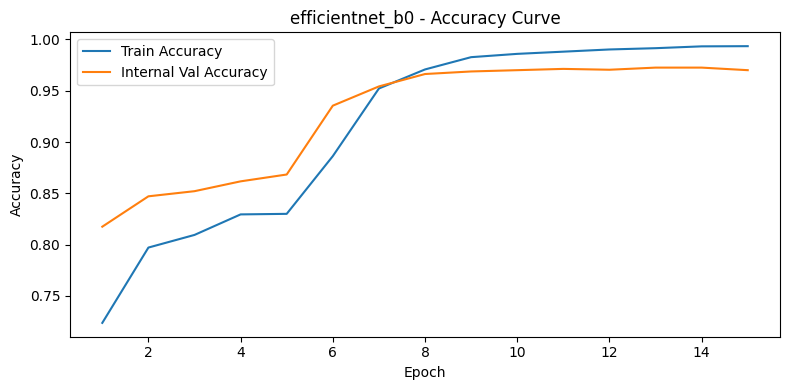

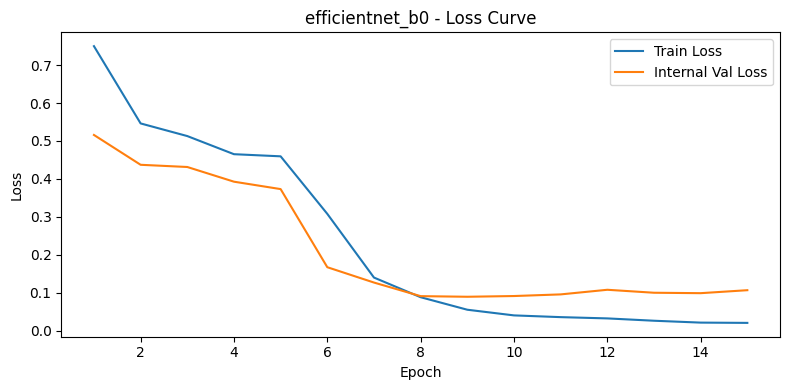

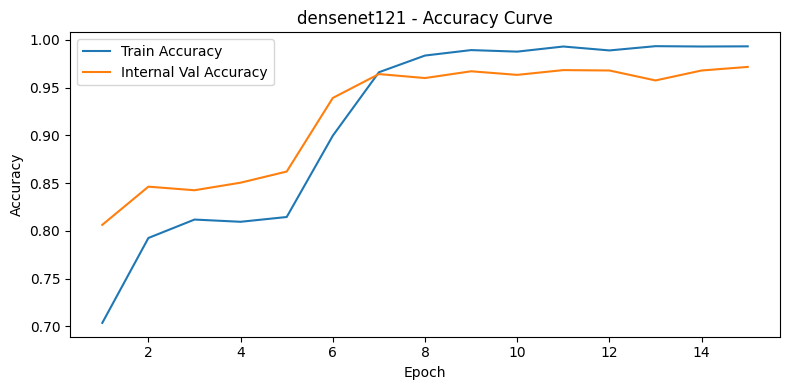

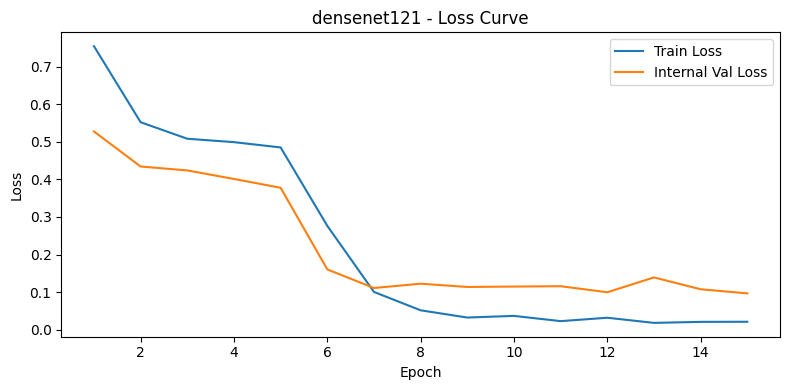

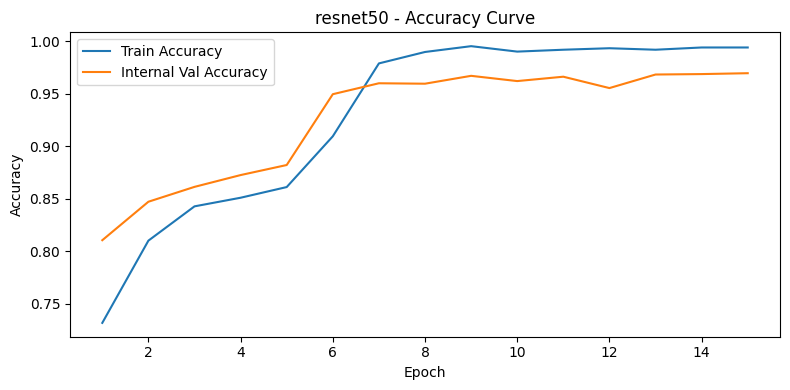

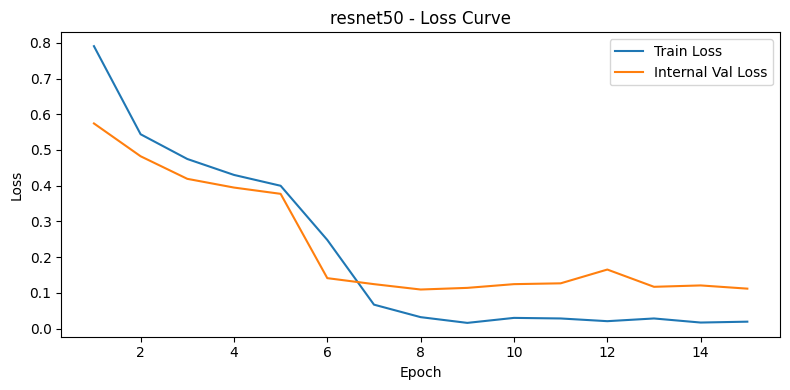

In [17]:
if "all_results" not in globals():
    print("all_results not available, cannot plot training curves.")
else:
    for model_name, result in all_results.items():
        history = result["history"]

        # Accuracy Curve
        plt.figure(figsize=(8, 4))
        plt.plot(history["epoch"], history["train_accuracy"], label="Train Accuracy")
        plt.plot(history["epoch"], history["val_accuracy"], label="Internal Val Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"{model_name} - Accuracy Curve")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"{model_name}_accuracy_curve.png")
        plt.show()

        # Loss Curve
        plt.figure(figsize=(8, 4))
        plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
        plt.plot(history["epoch"], history["val_loss"], label="Internal Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{model_name} - Loss Curve")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"{model_name}_loss_curve.png")
        plt.show()

## Evaluation

We report the following metrics for all models:

- **accuracy** — the proportion of predictions the model gets correct
- **loss** — the optimization error used to measure how far predictions are from true labels
- **precision** — among the samples predicted for a class, how many are actually correct
- **recall** — among the actual samples of a class, how many the model correctly identifies
- **F1-score** — the balance between precision and recall
- **confusion matrix** — a class-by-class summary of correct and incorrect predictions
- **classification report** — a detailed summary of precision, recall, F1-score, and support for each class

### What is a confusion matrix?
A confusion matrix shows how often each actual class was predicted as each possible class.

It helps identify:
- which classes are easy
- which classes are confused with each other

These evaluation metrics are computed separately for each model and used for final comparison across architectures.

In [18]:
def run_full_evaluation(model, model_name, loader, criterion, device, class_names, dataset_name="Dataset"):
    results = evaluate_model(model, loader, criterion, device)

    y_true = results["y_true"]
    y_pred = results["y_pred"]

    metrics = {
        "model_name": model_name,
        "dataset_name": dataset_name,
        "loss": results["loss"],
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "macro_precision": precision_score(y_true, y_pred, average="macro"),
        "macro_recall": recall_score(y_true, y_pred, average="macro"),
        "classification_report": classification_report(
            y_true, y_pred, target_names=class_names, output_dict=True
        ),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "y_true": y_true,
        "y_pred": y_pred
    }

    print(f"\n========== {model_name} | {dataset_name} ==========")
    print(f"Loss: {metrics['loss']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")
    print(f"Weighted F1: {metrics['weighted_f1']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall: {metrics['macro_recall']:.4f}")

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = np.array(metrics["confusion_matrix"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name} | {dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{model_name}_{dataset_name}_confusion_matrix.png")
    plt.show()

    return metrics

## Internal Validation Evaluation

This shows the performance of each model on the **30% internal validation split** used during model development.

This evaluation is used for:
- monitoring training performance
- selecting the best checkpoint for each model

Each model is evaluated independently using its best saved checkpoint.


========== efficientnet_b0 | Internal Validation ==========
Loss: 0.0990
Accuracy: 0.9725
Macro F1: 0.9725
Weighted F1: 0.9725
Macro Precision: 0.9725
Macro Recall: 0.9725

Classification Report
                      precision    recall  f1-score   support

            cataract       0.98      0.98      0.98       600
diabetic_retinopathy       1.00      0.99      0.99       600
            glaucoma       0.96      0.96      0.96       600
              normal       0.96      0.96      0.96       600

            accuracy                           0.97      2400
           macro avg       0.97      0.97      0.97      2400
        weighted avg       0.97      0.97      0.97      2400



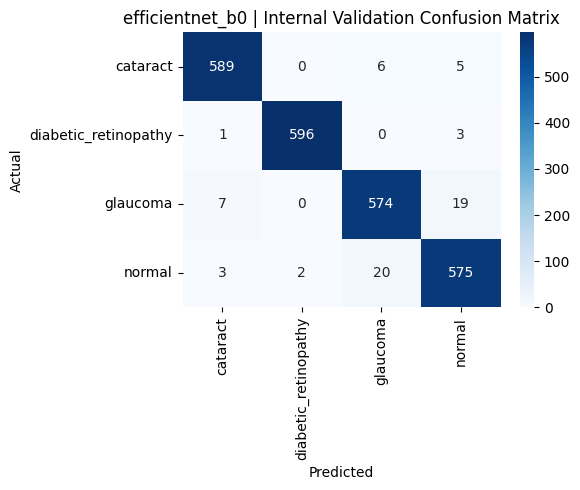


========== densenet121 | Internal Validation ==========
Loss: 0.0965
Accuracy: 0.9717
Macro F1: 0.9716
Weighted F1: 0.9716
Macro Precision: 0.9720
Macro Recall: 0.9717

Classification Report
                      precision    recall  f1-score   support

            cataract       0.96      0.99      0.98       600
diabetic_retinopathy       1.00      1.00      1.00       600
            glaucoma       0.98      0.93      0.95       600
              normal       0.95      0.97      0.96       600

            accuracy                           0.97      2400
           macro avg       0.97      0.97      0.97      2400
        weighted avg       0.97      0.97      0.97      2400



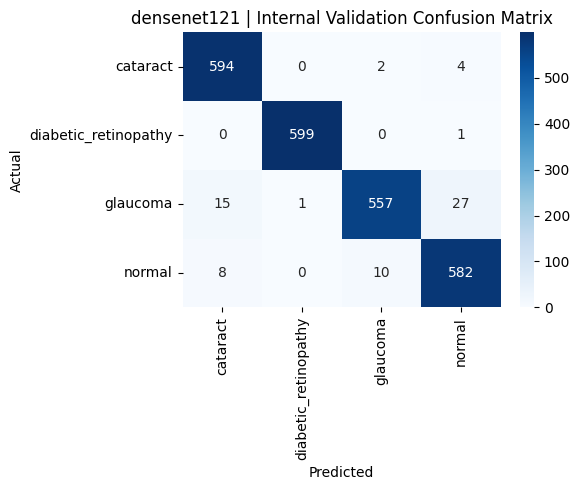


========== resnet50 | Internal Validation ==========
Loss: 0.1119
Accuracy: 0.9696
Macro F1: 0.9696
Weighted F1: 0.9696
Macro Precision: 0.9699
Macro Recall: 0.9696

Classification Report
                      precision    recall  f1-score   support

            cataract       0.98      0.96      0.97       600
diabetic_retinopathy       1.00      1.00      1.00       600
            glaucoma       0.94      0.97      0.95       600
              normal       0.96      0.95      0.95       600

            accuracy                           0.97      2400
           macro avg       0.97      0.97      0.97      2400
        weighted avg       0.97      0.97      0.97      2400



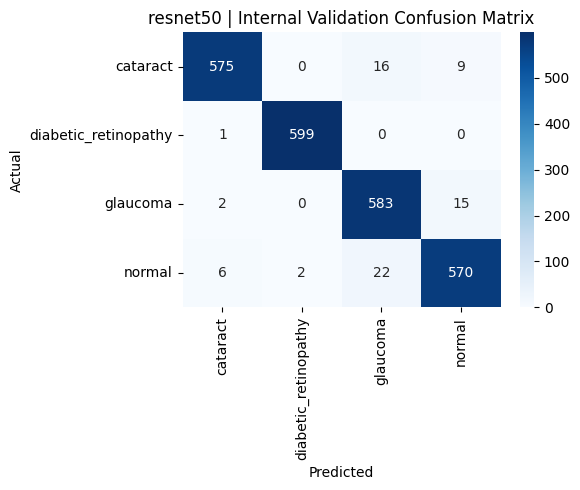

In [19]:
internal_val_results = {}

for model_name, model in loaded_models.items():
    metrics = run_full_evaluation(
        model=model,
        model_name=model_name,
        loader=internal_val_loader,
        criterion=criterion,
        device=DEVICE,
        class_names=class_names,
        dataset_name="Internal Validation"
    )

    internal_val_results[model_name] = metrics

## Holdout Validation Evaluation

This is the more important evaluation section because the holdout validation set was never used during training.

It provides a cleaner and more reliable estimate of how well each model generalizes to unseen data.

Each model is evaluated using its best checkpoint, and the results are used for final comparison across architectures.


========== efficientnet_b0 | Holdout Validation ==========
Loss: 0.3727
Accuracy: 0.9041
Macro F1: 0.9111
Weighted F1: 0.9026
Macro Precision: 0.9219
Macro Recall: 0.9125

Classification Report
                      precision    recall  f1-score   support

            cataract       0.87      1.00      0.93        20
diabetic_retinopathy       1.00      1.00      1.00        13
            glaucoma       0.82      0.90      0.86        20
              normal       1.00      0.75      0.86        20

            accuracy                           0.90        73
           macro avg       0.92      0.91      0.91        73
        weighted avg       0.91      0.90      0.90        73



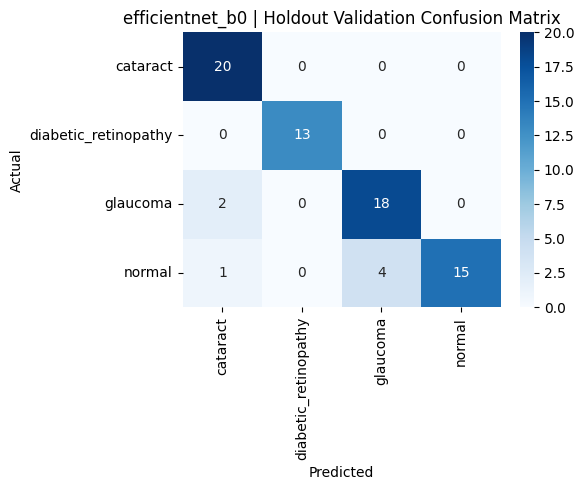


========== densenet121 | Holdout Validation ==========
Loss: 0.1911
Accuracy: 0.9315
Macro F1: 0.9368
Weighted F1: 0.9308
Macro Precision: 0.9378
Macro Recall: 0.9375

Classification Report
                      precision    recall  f1-score   support

            cataract       0.91      1.00      0.95        20
diabetic_retinopathy       1.00      1.00      1.00        13
            glaucoma       0.89      0.85      0.87        20
              normal       0.95      0.90      0.92        20

            accuracy                           0.93        73
           macro avg       0.94      0.94      0.94        73
        weighted avg       0.93      0.93      0.93        73



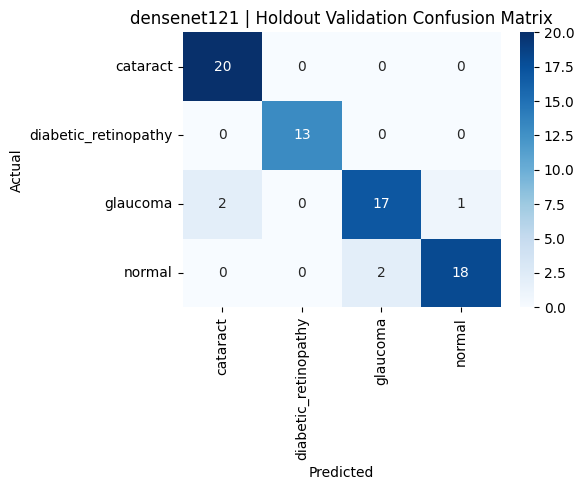


========== resnet50 | Holdout Validation ==========
Loss: 0.1357
Accuracy: 0.9452
Macro F1: 0.9505
Weighted F1: 0.9458
Macro Precision: 0.9528
Macro Recall: 0.9500

Classification Report
                      precision    recall  f1-score   support

            cataract       1.00      0.95      0.97        20
diabetic_retinopathy       1.00      1.00      1.00        13
            glaucoma       0.86      0.95      0.90        20
              normal       0.95      0.90      0.92        20

            accuracy                           0.95        73
           macro avg       0.95      0.95      0.95        73
        weighted avg       0.95      0.95      0.95        73



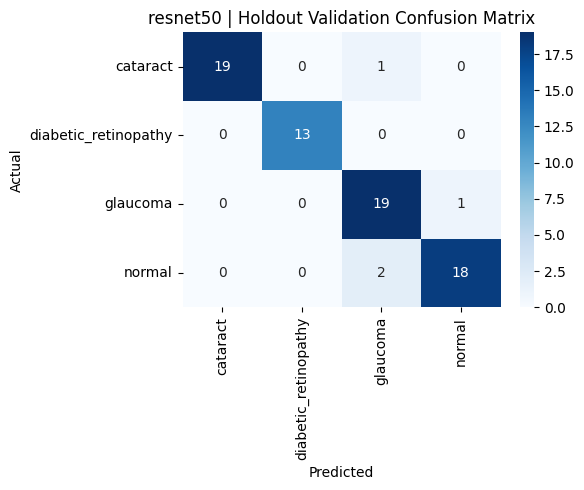

In [20]:
holdout_results = {}

for model_name, model in loaded_models.items():
    metrics = run_full_evaluation(
        model=model,
        model_name=model_name,
        loader=holdout_loader,
        criterion=criterion,
        device=DEVICE,
        class_names=class_names,
        dataset_name="Holdout Validation"
    )

    holdout_results[model_name] = metrics

## Saved Outputs

At this stage, the best model checkpoint for each model has already been saved in **`.pth`** format.

The notebook also saves:

- accuracy curve plots (per model)
- loss curve plots (per model)
- confusion matrix plots (per model and dataset)
- explainability visualizations

All outputs are stored separately for each model to support clear comparison and analysis.

In [21]:
print("Saved Outputs:")

for model_name, result in all_results.items():
    print(f"\nModel: {model_name}")
    print("Best Model Path:", result["best_model_path"])
    print("Accuracy Curve:", PLOT_DIR / f"{model_name}_accuracy_curve.png")
    print("Loss Curve:", PLOT_DIR / f"{model_name}_loss_curve.png")

Saved Outputs:

Model: efficientnet_b0
Best Model Path: models/efficientnet_b0_stage2_epoch_14_trainacc_0.9932_trainloss_0.0214_valacc_0.9725_valloss_0.0990_macrof1_0.9725.pth
Accuracy Curve: plots/efficientnet_b0_accuracy_curve.png
Loss Curve: plots/efficientnet_b0_loss_curve.png

Model: densenet121
Best Model Path: models/densenet121_stage2_epoch_15_trainacc_0.9932_trainloss_0.0210_valacc_0.9717_valloss_0.0965_macrof1_0.9716.pth
Accuracy Curve: plots/densenet121_accuracy_curve.png
Loss Curve: plots/densenet121_loss_curve.png

Model: resnet50
Best Model Path: models/resnet50_stage2_epoch_15_trainacc_0.9941_trainloss_0.0195_valacc_0.9696_valloss_0.1119_macrof1_0.9696.pth
Accuracy Curve: plots/resnet50_accuracy_curve.png
Loss Curve: plots/resnet50_loss_curve.png


## Error Analysis

Error analysis helps understand model behavior by identifying:

- which classes are frequently confused
- whether mistakes are random or systematic
- whether borderline disease cases need more attention

This analysis is performed separately for each model to compare error patterns across architectures.


========== Misclassified: efficientnet_b0 ==========

Misclassified examples found: 7


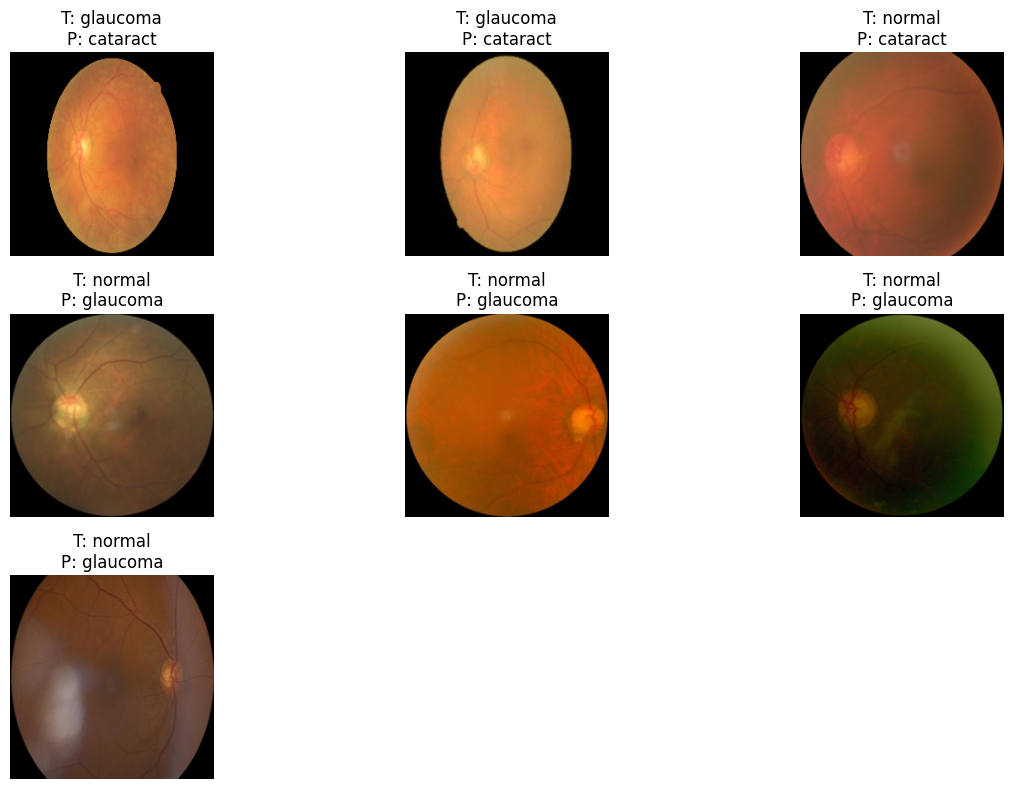


========== Misclassified: densenet121 ==========

Misclassified examples found: 5


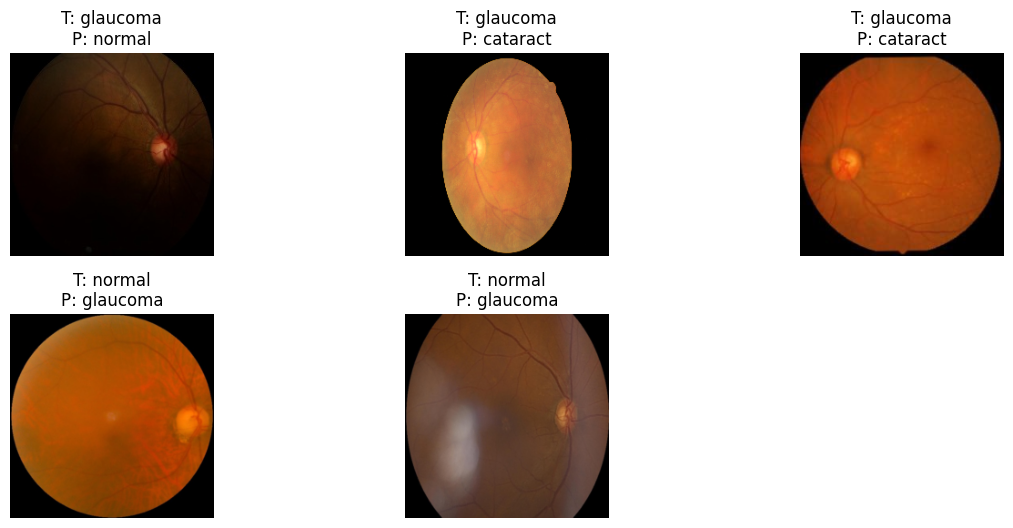


========== Misclassified: resnet50 ==========

Misclassified examples found: 4


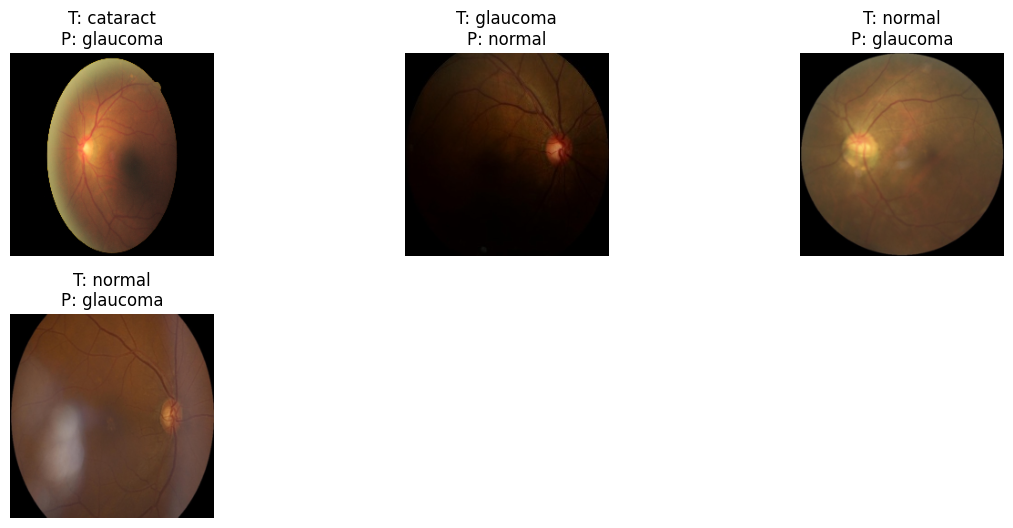

In [22]:
holdout_eval_dataset_for_display = datasets.ImageFolder(HOLDOUT_ROOT, transform=eval_transform)

def denormalize_image(tensor, mean, std):
    image = tensor.clone().cpu()
    for t, m, s in zip(image, mean, std):
        t.mul_(s).add_(m)
    image = image.permute(1, 2, 0).numpy()
    image = np.clip(image, 0, 1)
    return image

def get_misclassified_examples(model, dataset, device, max_examples=8):
    model.eval()
    wrong = []
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for idx, (image, label) in enumerate(loader):
            image = image.to(device)
            output = model(image)
            pred = torch.argmax(output, dim=1).item()

            if pred != label.item():
                wrong.append((idx, image.cpu().squeeze(0), label.item(), pred))

            if len(wrong) >= max_examples:
                break

    return wrong


# Run for all models and display in 3 rows
for model_name, model in loaded_models.items():
    print(f"\n========== Misclassified: {model_name} ==========\n")

    misclassified = get_misclassified_examples(
        model=model,
        dataset=holdout_eval_dataset_for_display,
        device=DEVICE,
        max_examples=9
    )

    print("Misclassified examples found:", len(misclassified))

    if len(misclassified) == 0:
        continue

    plt.figure(figsize=(12, 8))

    for i, (idx, img_tensor, true_label, pred_label) in enumerate(misclassified):
        plt.subplot(3, 3, i + 1)

        img = denormalize_image(img_tensor, imagenet_mean, imagenet_std)
        plt.imshow(img)
        plt.title(f"T: {class_names[true_label]}\nP: {class_names[pred_label]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Explainability

After training, we generate explainability outputs for the **best checkpoint of each model (EfficientNet-B0, DenseNet121, ResNet50)**.

This helps us understand how each model makes predictions and whether it focuses on meaningful regions in the eye images.

---

### Methods Used

We use three complementary explainability techniques:

#### 1. Grad-CAM
- highlights important regions in the image
- shows **where the model is looking**
- useful for verifying focus on relevant eye regions

#### 2. Occlusion Sensitivity
- masks parts of the image and observes prediction changes
- shows **which regions truly impact predictions**
- helps validate model reliance on meaningful features

---

### How Explainability is Applied

For each model:
- load the **best saved checkpoint**
- select sample images (correct + misclassified)
- generate:
  - Grad-CAM heatmaps
  - Occlusion maps
  - Integrated Gradients visualizations

---

### Why This Matters

Explainability helps:
- verify model is learning medically relevant patterns
- detect spurious correlations or biases
- understand failure cases
- build trust in model predictions

---

### Final Outcome

By comparing explainability outputs across models, we can:
- identify which model focuses on the most relevant regions
- understand differences in model behavior
- support model selection beyond just performance metrics

In [23]:
def get_raw_image_and_tensor(dataset, index):
    # Fetch image and label from dataset
    image_tensor, label = dataset[index]
    
    # Add batch dimension and move to device
    return image_tensor.unsqueeze(0).to(DEVICE), label


# Select one example image from holdout dataset
example_index = 0
input_tensor, true_label = get_raw_image_and_tensor(
    holdout_eval_dataset_for_display,
    example_index
)

# Print ground truth label
print("True label:", class_names[true_label])

# Run inference across all trained models
for model_name, model in loaded_models.items():
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient computation
        logits = model(input_tensor)  # Forward pass
        probs = torch.softmax(logits, dim=1)  # Convert to probabilities
        
        # Get predicted class and confidence
        pred_class = torch.argmax(probs, dim=1).item()
        pred_conf = probs[0, pred_class].item()

    # Print model-specific prediction
    print(f"\nModel: {model_name}")
    print("Pred label:", class_names[pred_class])
    print("Confidence:", round(pred_conf, 4))

True label: cataract

Model: efficientnet_b0
Pred label: cataract
Confidence: 1.0

Model: densenet121
Pred label: cataract
Confidence: 0.9976

Model: resnet50
Pred label: cataract
Confidence: 0.9998


## Grad-CAM

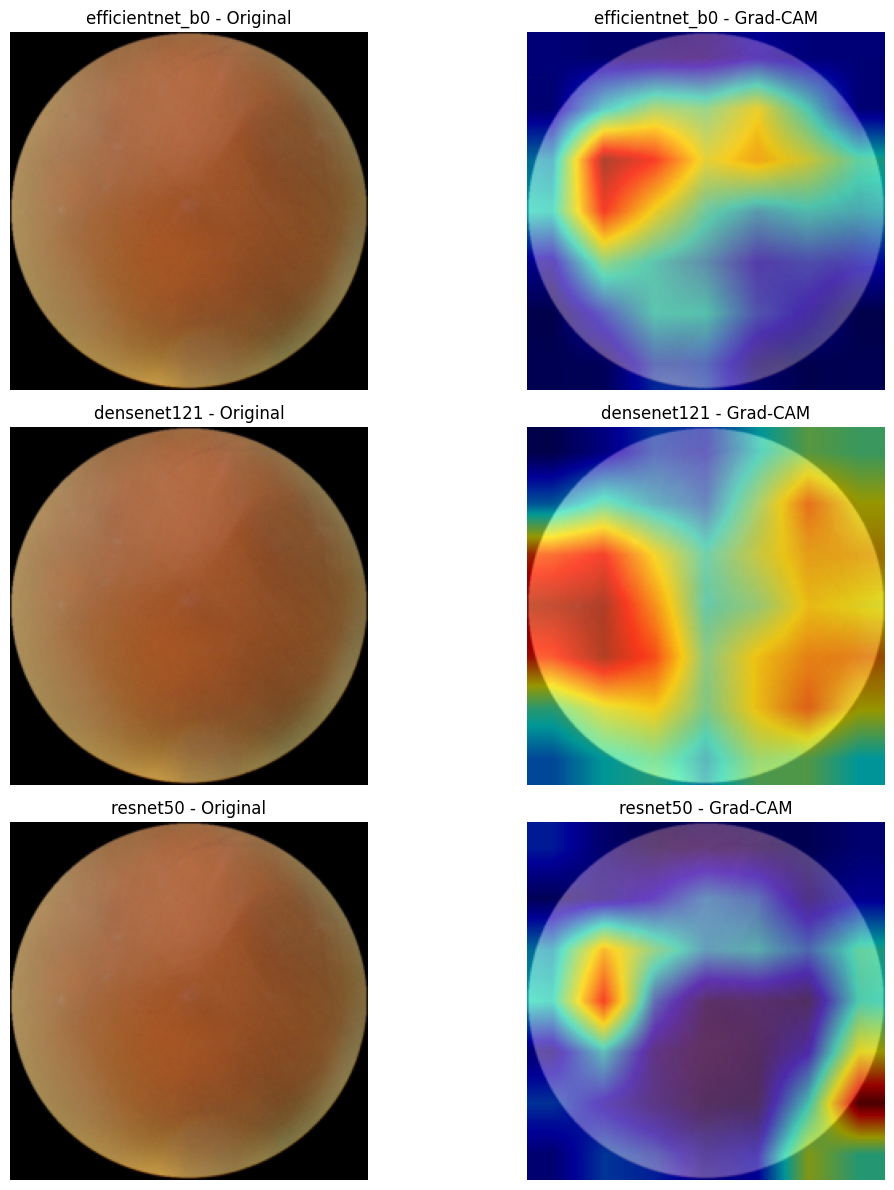

In [25]:
# Grad-CAM for all models

plt.figure(figsize=(12, 4 * len(loaded_models)))

for i, (model_name, model) in enumerate(loaded_models.items()):
    model.eval()

    # Model-specific target layer
    if model_name == "efficientnet_b0":
        target_layers = [model.features[-1]]
    elif model_name == "densenet121":
        target_layers = [model.features[-1]]
    elif model_name == "resnet50":
        target_layers = [model.layer4[-1]]
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    cam = GradCAM(model=model, target_layers=target_layers)

    # Forward pass to get prediction
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

    # Generate CAM
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(pred_class)]
    )[0]

    # Prepare images
    rgb_img = denormalize_image(input_tensor.squeeze(0), imagenet_mean, imagenet_std)
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot Original
    plt.subplot(len(loaded_models), 2, 2*i + 1)
    plt.imshow(rgb_img)
    plt.title(f"{model_name} - Original")
    plt.axis("off")

    # Plot Grad-CAM
    plt.subplot(len(loaded_models), 2, 2*i + 2)
    plt.imshow(cam_image)
    plt.title(f"{model_name} - Grad-CAM")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Occlusion Sensitivity

This method checks what happens when small parts of the image are hidden.

If prediction confidence drops when a region is hidden, that region is important.

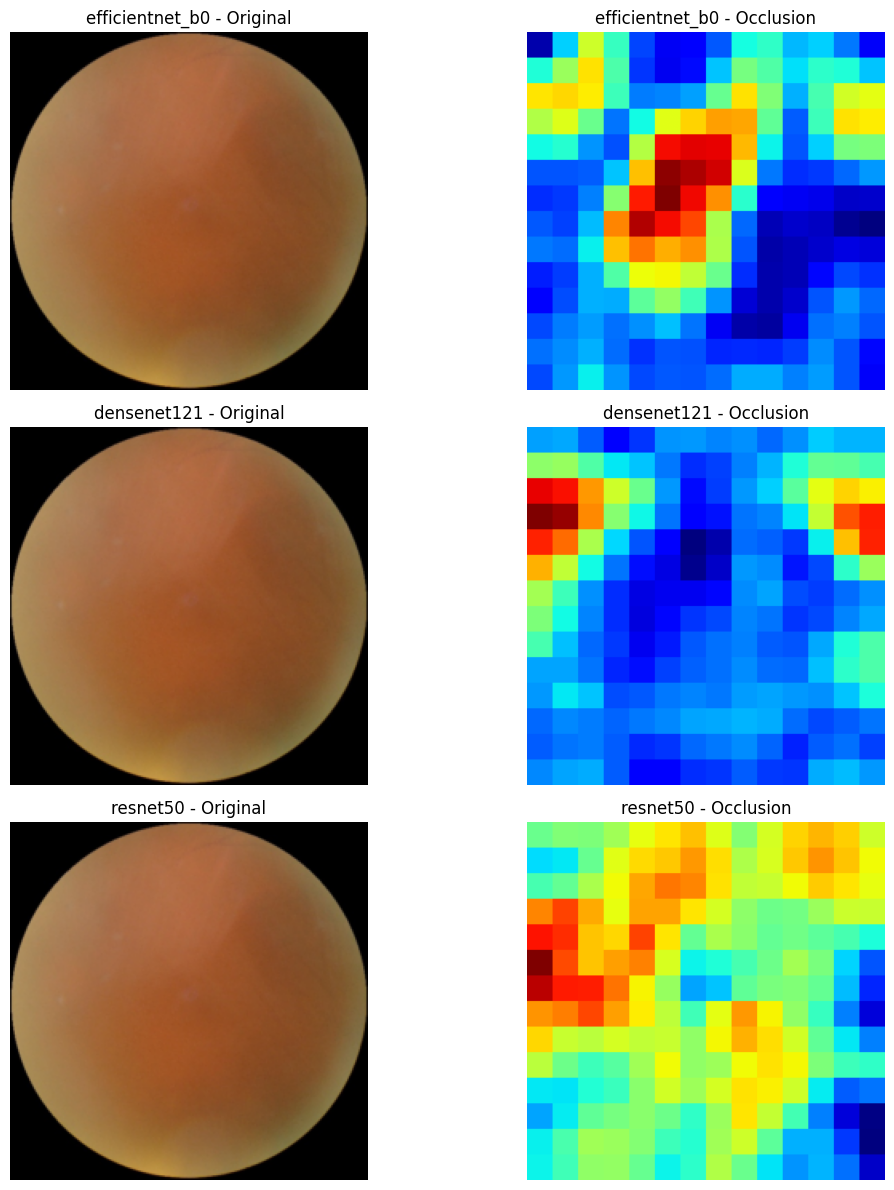

In [26]:
# Occlusion Sensitivity for all models

plt.figure(figsize=(12, 4 * len(loaded_models)))

for i, (model_name, model) in enumerate(loaded_models.items()):
    model.eval()

    # Forward pass to get prediction
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

    # Occlusion
    occlusion = Occlusion(model)

    attributions_occ = occlusion.attribute(
        input_tensor,
        strides=(3, 16, 16),
        target=pred_class,
        sliding_window_shapes=(3, 32, 32),
        baselines=0
    )

    # Convert attribution to heatmap
    occ_map = attributions_occ.squeeze(0).mean(dim=0).detach().cpu().numpy()

    # Normalize for better visualization
    occ_map = (occ_map - occ_map.min()) / (occ_map.max() - occ_map.min() + 1e-8)

    # Plot Original
    plt.subplot(len(loaded_models), 2, 2*i + 1)
    plt.imshow(rgb_img)
    plt.title(f"{model_name} - Original")
    plt.axis("off")

    # Plot Occlusion Map
    plt.subplot(len(loaded_models), 2, 2*i + 2)
    plt.imshow(occ_map, cmap="jet")
    plt.title(f"{model_name} - Occlusion")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Explainability Interpretation

For this example, the explainability results across **EfficientNet-B0, DenseNet121, and ResNet50** suggest that all models are primarily using information from **within the retinal region**, rather than relying on the black background.

---

### Grad-CAM

The Grad-CAM visualizations show how each model distributes its attention:

- **EfficientNet-B0**
  - Focuses on a localized region on the left-central retinal area
  - Attention is relatively concentrated and structured

- **DenseNet121**
  - Shows broader attention across multiple regions
  - Some spread toward edges, indicating less localized focus

- **ResNet50**
  - Highlights a smaller, sharper region
  - Also shows some scattered attention toward the periphery

#### Interpretation
- All models are focusing on the retinal region
- Attention patterns differ:
  - EfficientNet → more balanced
  - DenseNet → more diffuse
  - ResNet → more localized but slightly noisy

---

### Occlusion Sensitivity

The Occlusion maps provide a clearer view of **which regions actually impact predictions**:

- **EfficientNet-B0**
  - Strong central activation
  - Indicates reliance on a specific retinal region

- **DenseNet121**
  - Activation spread across left and right regions
  - Suggests multiple contributing areas

- **ResNet50**
  - Broader activation pattern
  - Less sharply defined important regions

#### Interpretation
- All models depend on **internal retinal regions**
- EfficientNet shows the most **focused dependency**
- DenseNet and ResNet rely on **more distributed signals**

---

### Cross-Model Insight

Comparing both methods:

- Grad-CAM shows **where models look**
- Occlusion shows **what actually matters**

Across models:
- No model is relying on background artifacts
- All are extracting signals from meaningful retinal regions
- Differences lie in **how concentrated vs distributed the attention is**

---

## Overall Conclusion

For this sample:

- All models are using **retinal content for prediction**
- EfficientNet-B0 shows the most **consistent and focused attention**
- DenseNet121 captures **broader contextual patterns**
- ResNet50 shows **localized but slightly noisy focus**

Occlusion Sensitivity provides the **clearest indication of important regions** across all models.

---

## Important Note

These explainability outputs:

- do **not confirm clinical correctness**
- do **not guarantee lesion-level accuracy**

They only indicate **which regions influenced the model’s prediction**, not whether those regions correspond to medically correct features.

## Model Performance Summary and Comparison

This section summarizes the performance of all three models (**EfficientNet-B0, DenseNet121, ResNet50**) across both internal validation and holdout datasets.

---

## Internal Validation Performance

All three models show **very strong and similar performance** on the internal validation split.

### Key Observations

- **EfficientNet-B0**
  - Accuracy: ~0.9725
  - Very balanced performance across all classes
  - Slight confusion between *glaucoma* and *normal*

- **DenseNet121**
  - Accuracy: ~0.9717
  - Strong performance on *diabetic_retinopathy*
  - Slightly higher confusion in *glaucoma* predictions

- **ResNet50**
  - Accuracy: ~0.9696
  - Stable overall performance
  - Slightly more confusion between *cataract* and *glaucoma*

### Internal Validation Insight

- All models perform **almost equally well**
- Differences are minor and within a narrow margin
- No model shows a clear dominance at this stage

---

## Holdout Validation Performance (Generalization)

This is the **most important evaluation**, as it reflects real-world performance.

### Key Observations

- **EfficientNet-B0**
  - Accuracy: ~0.90
  - Slight drop from internal validation
  - Struggles slightly with *normal* and *glaucoma*

- **DenseNet121**
  - Accuracy: ~0.93
  - More stable generalization than EfficientNet
  - Better balance across all classes

- **ResNet50**
  - Accuracy: ~0.95 (best)
  - Strongest generalization performance
  - Most consistent confusion matrix

---

## Class-Level Behavior

### Cataract
- High performance across all models
- Very few misclassifications

### Diabetic Retinopathy
- Almost perfect classification in all models
- Easiest class for the models

### Glaucoma
- Most challenging class
- Frequently confused with:
  - normal
  - cataract (in some cases)

### Normal
- Moderate confusion with glaucoma
- Slight performance variation across models

---

## Generalization Gap Analysis

- All models show a **performance drop** from internal → holdout
- Indicates:
  - slight overfitting to training distribution
  - dataset shift between training and holdout

However:
- DenseNet121 and ResNet50 handle this better than EfficientNet

---

## Final Model Comparison

| Model            | Internal Acc | Holdout Acc | Generalization |
|------------------|-------------|-------------|----------------|
| EfficientNet-B0  | ~0.9725     | ~0.9041     | Moderate       |
| DenseNet121      | ~0.9717     | ~0.9315     | Strong         |
| ResNet50         | ~0.9696     | ~0.9452     | Best           |

---

## Final Conclusion

- **ResNet50 is the best performing model overall**
  - highest holdout accuracy
  - most consistent predictions
  - strongest generalization

- **DenseNet121 is a close second**
  - very stable
  - slightly lower than ResNet50 but reliable

- **EfficientNet-B0 performs well but generalizes less effectively**
  - higher drop in holdout performance

---

## Practical Recommendation

- Use **ResNet50** as the primary model for deployment
- Consider **DenseNet121** as a strong alternative
- Use EfficientNet only if:
  - computational efficiency is a priority
  - further tuning is planned

---

## Key Takeaways

- All models learn meaningful retinal features
- Performance differences appear mainly in **generalization**
- **Glaucoma vs Normal** remains the hardest distinction
- Final model selection should prioritize **holdout performance**, not internal validation